In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df_train = pd.read_csv("AppML_InitialProject_train.csv")
df_train = df_train.drop(columns=["p_Truth_isElectron"])
df_test = pd. read_csv("AppML_InitialProject_test_regression.csv")

df_train.shape

(180000, 141)

In [8]:
df_train

,averageInteractionsPerCrossing,p_Rhad1,p_Rhad,p_f3,p_weta2,p_Rphi,p_Reta,p_Eratio,p_f1,p_TRTPID,...,pX_E7x11_Lr1,pX_E7x11_Lr2,pX_E7x11_Lr3,pX_E7x7_Lr0,pX_E7x7_Lr1,p_pt_track,p_eta,p_phi,p_charge,p_Truth_Energy
0,55.50,-0.002390,-0.003614,0.000744,0.010088,0.947685,0.983722,0.969448,0.355275,-0.030026,...,16208.0300,27951.328,473.046360,1415.2955,16208.0300,38339.8750,0.725108,2.511338,-1.0,46673.574
1,33.50,-0.009279,-0.010666,0.003784,0.011625,0.922366,0.955934,0.918366,0.397633,0.335419,...,28639.7420,34642.820,86.462740,11456.5240,28639.7420,26470.8900,1.566765,-0.593568,-1.0,85356.500
2,35.50,0.002806,0.013643,0.025505,0.010330,0.969845,0.945576,0.921568,0.077971,0.517517,...,8061.6840,88892.890,2173.160200,0.0000,8061.6840,32989.9570,1.926261,2.497809,-1.0,103427.160
3,40.49,-0.001910,0.000044,0.000176,0.010323,0.923816,0.888029,0.000000,0.000000,0.133801,...,27257.8890,39768.450,102.033676,35418.3050,27154.4340,86615.2340,1.510641,2.441266,-1.0,163799.640
4,52.50,0.013779,-0.002106,0.010156,0.010096,0.899883,0.717177,0.782584,0.253658,-0.044038,...,6206.0938,15531.818,277.199130,1242.5723,6206.0938,17362.5060,-0.113342,3.003595,-1.0,16997.960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179995,48.50,0.664485,0.785885,0.030614,0.013458,0.706411,0.803551,0.176808,0.310948,0.090996,...,9420.7740,19028.691,1456.618000,2519.9902,9452.5410,21610.8260,-0.333357,2.638398,1.0,22591.540
179996,45.49,0.626207,0.890136,0.002500,0.011333,0.933887,0.870006,0.887657,0.288254,-0.153530,...,7939.0913,14750.185,995.310060,3643.7200,7939.0913,19252.5310,-1.206471,-1.202972,1.0,33412.470
179997,49.50,0.068849,0.099816,0.017091,0.013220,0.777033,0.898677,0.127255,0.378862,-0.000000,...,22392.7870,48182.340,697.059200,0.0000,22392.7870,3583.9360,2.352615,-2.420230,-1.0,-999.000
179998,39.49,0.688895,1.168897,0.009258,0.012657,0.503309,0.734173,0.092843,0.412541,-0.320695,...,20544.4140,26506.123,976.097800,8783.8370,20544.4140,7410.3380,-1.650526,-1.739836,-1.0,18125.062


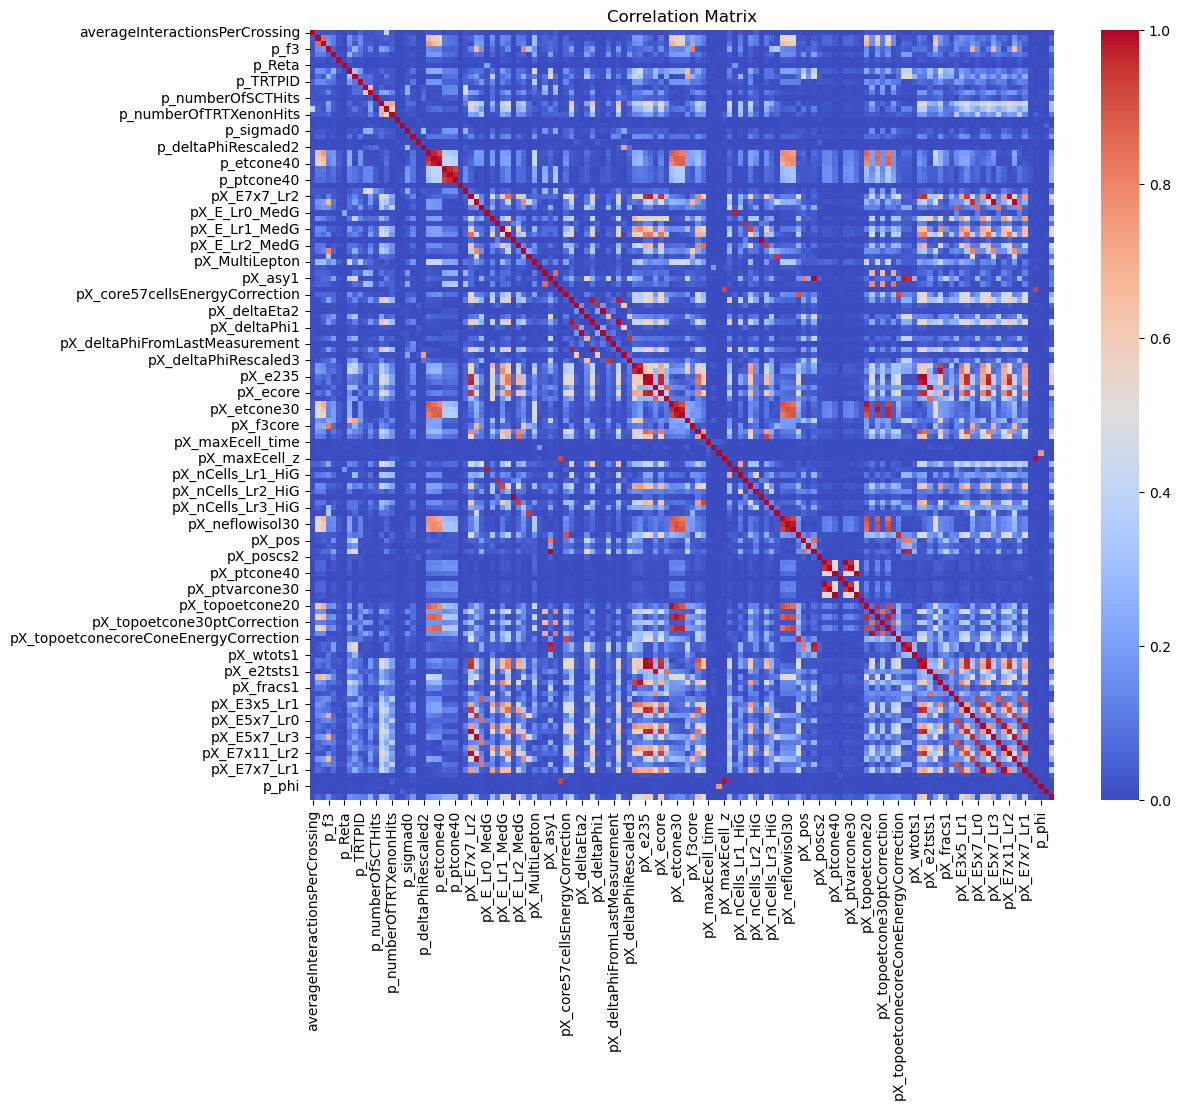

In [9]:
corr = df_train.corr().abs()

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    linewidths=0
)


plt.title("Correlation Matrix")
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
import shap
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

In [17]:
X = df_train.drop(columns=["p_Truth_Energy"])
y = df_train["p_Truth_Energy"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
)

In [19]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, preds))

print("RMSE:", rmse)

RMSE: 15353.218637108257


In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_valid, preds)
r2 = r2_score(y_valid, preds)

print(mae)
print(r2)

5857.804695084292
0.8963120360441066


In [21]:
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
)

preds = model.predict(X_valid)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29720
[LightGBM] [Info] Number of data points in the train set: 126000, number of used features: 136
[LightGBM] [Info] Start training from score 38760.946626


In [23]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_valid, preds)
r2 = r2_score(y_valid, preds)

print(mae)
print(r2)

5857.804695084292
0.8963120360441066


In [24]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance.head(20))

                             feature  importance
136                       p_pt_track        2162
18                         p_sigmad0        1029
17                              p_d0         998
137                            p_eta         956
100  pX_ptconecoreTrackPtrCorrection         914
19                         p_dPOverP         878
28                          p_ptPU30         594
73                pX_maxEcell_energy         464
37                      pX_E_Lr2_HiG         461
66                          pX_ecore         446
21               p_deltaPhiRescaled2         428
12                 p_numberOfSCTHits         422
47                         pX_barys1         393
36                     pX_E_Lr1_MedG         388
20                       p_deltaEta1         387
39                     pX_E_Lr2_MedG         384
57    pX_deltaPhiFromLastMeasurement         353
48    pX_core57cellsEnergyCorrection         353
104              pX_r33over37allcalo         339
34                  

In [25]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_valid,
    y_valid,
    n_repeats=5,
    random_state=42
)

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
})

importance.sort_values(
    by="importance",
    ascending=False,
    inplace=True
)

In [32]:
importance

,feature,importance
136,p_pt_track,0.458726
66,pX_ecore,0.094816
137,p_eta,0.045994
18,p_sigmad0,0.036609
100,pX_ptconecoreTrackPtrCorrection,0.022002
...,...,...
83,pX_nCells_Lr1_MedG,-0.000053
87,pX_nCells_Lr3_HiG,-0.000082
41,pX_E_Lr3_MedG,-0.000101
108,pX_topoetcone30ptCorrection,-0.000145


In [26]:
importance.head(20)

,feature,importance
136,p_pt_track,0.458726
66,pX_ecore,0.094816
137,p_eta,0.045994
18,p_sigmad0,0.036609
100,pX_ptconecoreTrackPtrCorrection,0.022002
73,pX_maxEcell_energy,0.014560
42,pX_MultiLepton,0.013983
17,p_d0,0.013264
13,p_numberOfTRTHits,0.011326
53,pX_deltaPhi0,0.009985


In [ ]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.01)
model.fit(X_train, y_train)

importance_lasso = pd.Series(
    model.coef_,
    index=X.columns
)

/home/jona/micromamba/envs/appmlenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.626e+13, tolerance: 2.403e+10
  model = cd_fast.enet_coordinate_descent(


In [35]:
importance_lasso.sort_values()
importance_lasso.tail(20)

pX_fracs1       2377.510257
pX_DeltaE         -1.760537
pX_E3x5_Lr0        0.446527
pX_E3x5_Lr1        0.011076
pX_E3x5_Lr2        0.210280
pX_E3x5_Lr3        0.545008
pX_E5x7_Lr0        0.140892
pX_E5x7_Lr1        0.234573
pX_E5x7_Lr2        0.006728
pX_E5x7_Lr3        0.214130
pX_E7x11_Lr0      -0.104830
pX_E7x11_Lr1      -0.126917
pX_E7x11_Lr2      -0.161797
pX_E7x11_Lr3      -0.359821
pX_E7x7_Lr0       -0.004119
pX_E7x7_Lr1        0.011844
p_pt_track         0.016472
p_eta           1291.803696
p_phi            -74.322251
p_charge         129.675603
dtype: float64

In [36]:
top20 = importance.head(20)["feature"].tolist()

X_train_top = X_train[top20]
X_valid_top = X_valid[top20]

In [38]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_top, y_train)

preds = model.predict(X_valid_top)

rmse = np.sqrt(mean_squared_error(y_valid, preds))

print("RMSE:", rmse)

RMSE: 15147.99512366347
